# Task 3: Predictive Analysis & XAI

## Project Goal and Problem Formulation
The goal of this task is to predict the **school of origin** (Macro-Zone) of an artist based on the audio features and metadata of their tracks.
Since the dataset contains many specific regions (e.g., Lombardia, Campania, Lazio), we aggregate them into broader **Macro-Zones** to define the class labels. This aggregation is based on shared musical characteristics and cultural similarities within the Italian Hip-Hop scene.

### Macro-Zone Mapping Rationale
We defined the class labels by aggregating regions into three distinct macro-zones:
* **North (Industrial/Urban Hubs):** Includes *Lombardia, Piemonte, Veneto, Liguria*. This zone is characterized by the industrial Hip-Hop scene and strong Trap influences.
* **South & Islands (Melodic/Dialectal Tradition):** Includes *Campania, Puglia, Sicilia, Sardegna*. This zone is culturally cohesive, often featuring strong melodic traditions, dialectal lyrics, and specific sub-genres like Neomelodic Rap.
* **Center (Transitional Zone):** Includes *Lazio, Toscana, Emilia-Romagna, Marche*. Dominated by the Roman scene, acting as a bridge between Northern and Southern styles.

## 1. Data Loading and Merging

We load three datasets:
- **tracks_enriched.csv**: Contains track metadata (title, popularity, duration, etc.)
- **artists.csv**: Contains artist information including their **region of origin**
- **merged_dataset_clean.csv**: Contains the 14 engineered features from clustering analysis

The merge process:
1. Align tracks with clustering features by index (first 8,144 tracks)
2. Join tracks with artists using `id_artist` to get region information
3. Remove duplicate columns before concatenating clustering features
4. Result: Complete dataset with region labels and musical features

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.inspection import permutation_importance
import shap
import lime
import lime.lime_tabular
import warnings

warnings.filterwarnings('ignore')

# Load datasets
tracks = pd.read_csv("../enriched_datasets/tracks_enriched.csv")
artists = pd.read_csv("../enriched_datasets/artists.csv")
clustering_features = pd.read_csv("../clustering_dataset/merged_dataset_clean.csv")

# Add index to track which tracks have clustering features
tracks_with_features = tracks.iloc[:len(clustering_features)].copy()

# Merge tracks with artists to get region information
df_base = tracks_with_features.merge(artists, left_on='id_artist', right_on='id_author', how='inner')

# Drop columns from df_base that exist in clustering_features to avoid duplicates
clustering_cols = clustering_features.columns.tolist()
cols_to_drop = [col for col in df_base.columns if col in clustering_cols]
df_base_clean = df_base.drop(columns=cols_to_drop)

# Merge clustering features (they should align by index now)
df = pd.concat([df_base_clean.reset_index(drop=True), clustering_features.reset_index(drop=True)], axis=1)

print(f"Final merged dataset shape: {df.shape}")
print(f"Number of tracks with complete features: {len(df)}")

# Check available regions
print("\nRegion counts:")
print(df['region'].value_counts())

Final merged dataset shape: (8144, 71)
Number of tracks with complete features: 8144

Region counts:
region
Lombardia         2996
Campania          1494
Lazio             1117
Piemonte           546
Veneto             408
Sardegna           340
Liguria            234
Puglia             180
Emilia-Romagna      99
Sicilia             92
Marche              47
Toscana             32
Name: count, dtype: int64


## 2. Baseline Analysis: 3-Class Mapping (Macro-Zones)

**Objective:**
First, we establish a baseline by classifying tracks into the three standard Italian geographical macro-zones: **North, Center, and South**.

**Methodology:**
* **Mapping:**
    * *North:* Lombardia, Piemonte, Veneto, Liguria
    * *Center:* Lazio, Toscana, Emilia-Romagna, Marche
    * *South:* Campania, Puglia, Sicilia, Calabria, Sardegna
* **Goal:** Evaluate if broader geographical regions align with distinct musical styles using our extracted features.

Distribution of 3 macro-zones:
school_3
North     4184
South     2106
Center    1295
Name: count, dtype: int64

Total samples: 7585


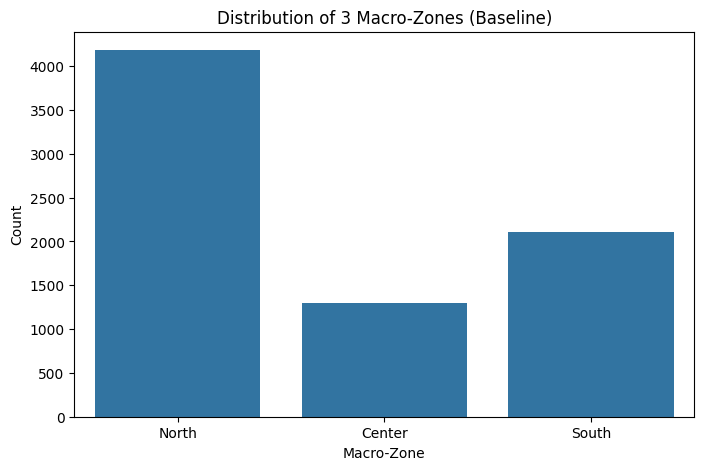

In [188]:
def map_region_to_3_classes(region):
    """Map Italian regions to 3 traditional macro-zones."""
    if pd.isna(region):
        return None
    
    north = ['Lombardia', 'Piemonte', 'Veneto', 'Liguria']
    center = ['Lazio', 'Toscana', 'Emilia-Romagna', 'Marche']
    south = ['Campania', 'Puglia', 'Sicilia', 'Calabria', 'Sardegna']
    
    if region in north:
        return 'North'
    elif region in center:
        return 'Center'
    elif region in south:
        return 'South'
    else:
        return None

# Apply 3-class mapping
df['school_3'] = df['region'].apply(map_region_to_3_classes)
df_clean_3 = df.dropna(subset=['school_3'])

print("Distribution of 3 macro-zones:")
print(df_clean_3['school_3'].value_counts())
print(f"\nTotal samples: {len(df_clean_3)}")

# Visualize distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean_3, x='school_3', order=['North', 'Center', 'South'])
plt.title('Distribution of 3 Macro-Zones (Baseline)')
plt.xlabel('Macro-Zone')
plt.ylabel('Count')
plt.show()

### Baseline Model Training and Evaluation
Before implementing complex algorithms or feature engineering, we establish a **baseline performance**.
We train a standard **Random Forest** on the original features.

**Objective:**
1.  Quantify the difficulty of the classification task.
2.  Highlight potential issues such as **Overfitting** (high train accuracy vs. low test accuracy).
3.  Visualize the impact of **Class Imbalance** (the model might ignore minority classes like 'Center').

Encoded classes: {'Center': np.int64(0), 'North': np.int64(1), 'South': np.int64(2)}

Dataset split:
  Train set: 6068 samples
  Test set: 1517 samples

Class distribution:
  Train: {'Center': np.int64(1036), 'North': np.int64(3347), 'South': np.int64(1685)}
  Test: {'Center': np.int64(259), 'North': np.int64(837), 'South': np.int64(421)}

BASELINE MODEL: Random Forest (3 Classes)

Train Accuracy: 1.0000
Test Accuracy: 0.6473

------------------------------------------------------------
Classification Report (Test Set):
------------------------------------------------------------
              precision    recall  f1-score   support

      Center       0.64      0.25      0.36       259
       North       0.64      0.94      0.76       837
       South       0.73      0.31      0.43       421

    accuracy                           0.65      1517
   macro avg       0.67      0.50      0.52      1517
weighted avg       0.66      0.65      0.60      1517



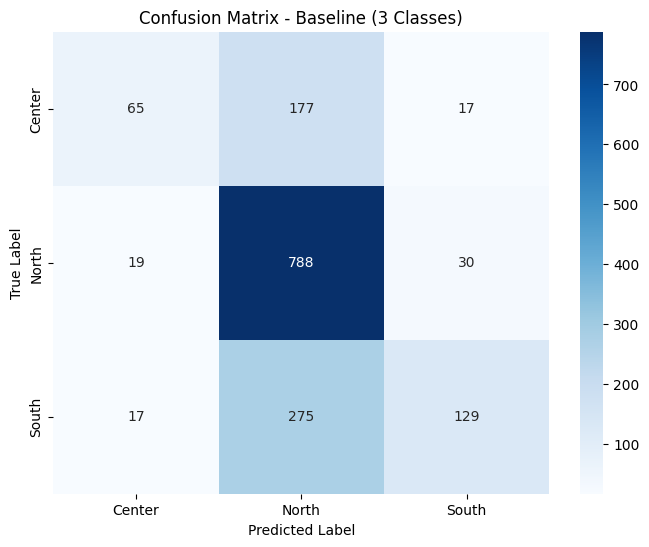


Per-class accuracy:
  Center: 0.2510 (65/259)
  North: 0.9415 (788/837)
  South: 0.3064 (129/421)


In [189]:
# Prepare features and target for 3-class baseline
features_3 = [
    'avg_token_per_clause', 'duration_ms', 'popularity', 'swear_ratio',
    'syntactic_complexity', 'flow_complexity', 'percussiveness', 'harmonic_richness',
    'trap_index', 'boombap_index', 'cloud_rap_index', 'drill_index',
    'career_longevity', 'years_since_release'
 ]

X_3 = df_clean_3[features_3].copy()
X_3 = X_3.fillna(X_3.mean())  # Handle missing values
y_3 = df_clean_3['school_3']

# Encode labels
le_3 = LabelEncoder()
y_3_encoded = le_3.fit_transform(y_3)
print(f"Encoded classes: {dict(zip(le_3.classes_, le_3.transform(le_3.classes_)))}")

# Train/Test split (80/20)
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X_3, y_3_encoded, test_size=0.20, random_state=42, stratify=y_3_encoded
)

print(f"\nDataset split:")
print(f"  Train set: {len(y_train_3)} samples")
print(f"  Test set: {len(y_test_3)} samples")

# Class distribution
print(f"\nClass distribution:")
for name, y_subset in [("Train", y_train_3), ("Test", y_test_3)]:
    unique, counts = np.unique(y_subset, return_counts=True)
    dist = dict(zip(le_3.inverse_transform(unique), counts))
    print(f"  {name}: {dist}")

# Scale features
scaler_3 = StandardScaler()
X_train_3_scaled = scaler_3.fit_transform(X_train_3)
X_test_3_scaled = scaler_3.transform(X_test_3)

# Train Random Forest baseline model
print("\n" + "=" * 60)
print("BASELINE MODEL: Random Forest (3 Classes)")
print("=" * 60)

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_3_scaled, y_train_3)

# Predictions
y_pred_train_3 = rf_baseline.predict(X_train_3_scaled)
y_pred_test_3 = rf_baseline.predict(X_test_3_scaled)

# Evaluation
acc_train_3 = accuracy_score(y_train_3, y_pred_train_3)
acc_test_3 = accuracy_score(y_test_3, y_pred_test_3)

print(f"\nTrain Accuracy: {acc_train_3:.4f}")
print(f"Test Accuracy: {acc_test_3:.4f}")

print("\n" + "-" * 60)
print("Classification Report (Test Set):")
print("-" * 60)
print(classification_report(y_test_3, y_pred_test_3, target_names=le_3.classes_))

# Confusion Matrix
cm_3 = confusion_matrix(y_test_3, y_pred_test_3)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_3.classes_, yticklabels=le_3.classes_)
plt.title('Confusion Matrix - Baseline (3 Classes)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, class_name in enumerate(le_3.classes_):
    class_acc = cm_3[i, i] / cm_3[i].sum() if cm_3[i].sum() > 0 else 0
    print(f"  {class_name}: {class_acc:.4f} ({cm_3[i, i]}/{cm_3[i].sum()})")

### Baseline Analysis Conclusions

**Key Observations:**
1. **Performance Level**: The baseline accuracy indicates how well we can distinguish the 3 traditional macro-zones.
2. **Confusion Patterns**: The confusion matrix reveals which regions are being misclassified.
   - If Lazio tracks (grouped in Center) are frequently classified as South, it suggests Rome's scene shares more similarity with Naples.
   - If Campania tracks (grouped in South) are classified as Center or North, it indicates Naples has distinct characteristics.
3. **Feature Importance**: Shows which musical features best separate the macro-zones.

**Motivation for 5-Class Refinement:**
Based on the analysis, we observe that **Lombardia (Milan)** and **Campania (Naples)** exhibit distinct characteristics that differentiate them from their respective macro-zones.

Additionally, **Lombardia** is the most populated region in the North, representing a dominant portion of the data and the Italian rap scene. To capture these unique regional rap identities and account for Lombardia's prominence, we will refine our classification task by separating these regions from the traditional macro-zones.

**New Class Structure:**
1. **North** (excluding Lombardia)
2. **Center**
3. **South** (excluding Campania)
4. **Lombardia** (Milan scene)
5. **Campania** (Naples scene)

This separation allows us to isolate the specific stylistic features of the Milan and Naples scenes, potentially improving the overall classification performance and providing deeper insights into the Italian rap landscape.

---

Let's now proceed with the **refined 5-class analysis** to test this hypothesis.

## 3. Refined Analysis: 5-Class Mapping (Schools)

**Motivation:**
The baseline analysis (3 classes) revealed potential weaknesses, particularly in distinguishing the "Center" and "South" macro-zones. The Italian rap scene is heavily influenced by specific local "schools" that have strong, distinct identities which might be diluted in broader macro-zones.

**New Strategy:**
We introduce a more granular mapping with **5 Classes**, explicitly isolating the two most historically significant scenes:
1.  **Lombardia (Milan School):** Separated from the North.
2.  **Campania (Naples School):** Separated from the South.
3.  **North:** Northen regions excluding Lombardia (Milan).
4.  **Center:** All Center regions as a single macro-group.
5.  **South (remaining):** South regions excluding Campania (Naples).

**Model Configuration:**
To handle class imbalance (the Lombardia is still the majority class), we will apply `class_weight='balanced'` to our models where applicable.

We explicitly set `max_depth=10` to mitigate overfitting. Without this constraint, Random Forest trees tend to grow indefinitely, memorizing the training noise and resulting in poor generalization on unseen data (as seen in the baseline).

Distribution of 5 classes:
school_5
Lombardia    2996
Campania     1494
Center       1295
North        1188
South         612
Name: count, dtype: int64

Total samples: 7585


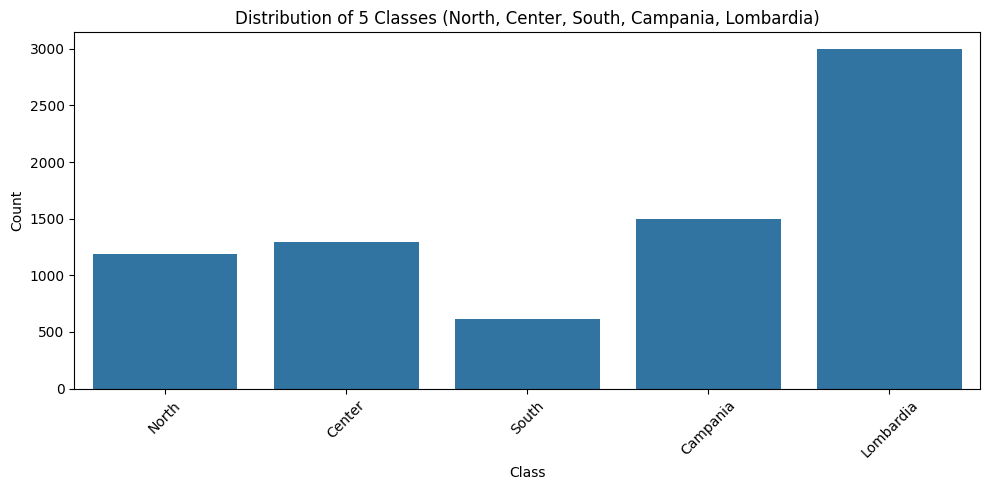

In [190]:
def map_region_to_5_classes(region):
    """Map Italian regions to 5 refined classes: isolate Rome and Naples schools."""
    if pd.isna(region):
        return None
    
    # Isolate the two most influential schools as separate classes
    if region == 'Campania':
        return 'Campania'
    if region == 'Lombardia':
        return 'Lombardia'
    
    # Remaining macro-zones (without Rome and Naples)
    north = ['Piemonte', 'Veneto', 'Liguria']
    center = ['Toscana', 'Emilia-Romagna', 'Marche', 'Lazio']
    south = ['Puglia', 'Sicilia', 'Calabria', 'Sardegna']
    
    if region in north:
        return 'North'
    elif region in center:
        return 'Center'
    elif region in south:
        return 'South'
    else:
        return None

# Apply the new 4-class mapping
df['school_5'] = df['region'].apply(map_region_to_5_classes)
df_clean_5 = df.dropna(subset=['school_5'])

print("Distribution of 5 classes:")
print(df_clean_5['school_5'].value_counts())
print(f"\nTotal samples: {len(df_clean_5)}")

# Visualize distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean_5, x='school_5', order=['North', 'Center', 'South', 'Campania','Lombardia'])
plt.title('Distribution of 5 Classes (North, Center, South, Campania, Lombardia)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Encoded classes: {'Campania': np.int64(0), 'Center': np.int64(1), 'Lombardia': np.int64(2), 'North': np.int64(3), 'South': np.int64(4)}

Dataset split:
  Train set: 6068 samples
  Test set: 1517 samples

Class distribution:
  Train: {'Campania': np.int64(1195), 'Center': np.int64(1036), 'Lombardia': np.int64(2397), 'North': np.int64(950), 'South': np.int64(490)}
  Test: {'Campania': np.int64(299), 'Center': np.int64(259), 'Lombardia': np.int64(599), 'North': np.int64(238), 'South': np.int64(122)}

RANDOM FOREST: 5 Classes (North, Center, South, Campania, Lombardia)

Train Accuracy: 0.8734
Test Accuracy: 0.5531
Overfitting Gap: 0.3204

------------------------------------------------------------
Classification Report (Test Set):
------------------------------------------------------------
              precision    recall  f1-score   support

    Campania       0.47      0.72      0.57       299
      Center       0.58      0.52      0.55       259
   Lombardia       0.69      0.51     

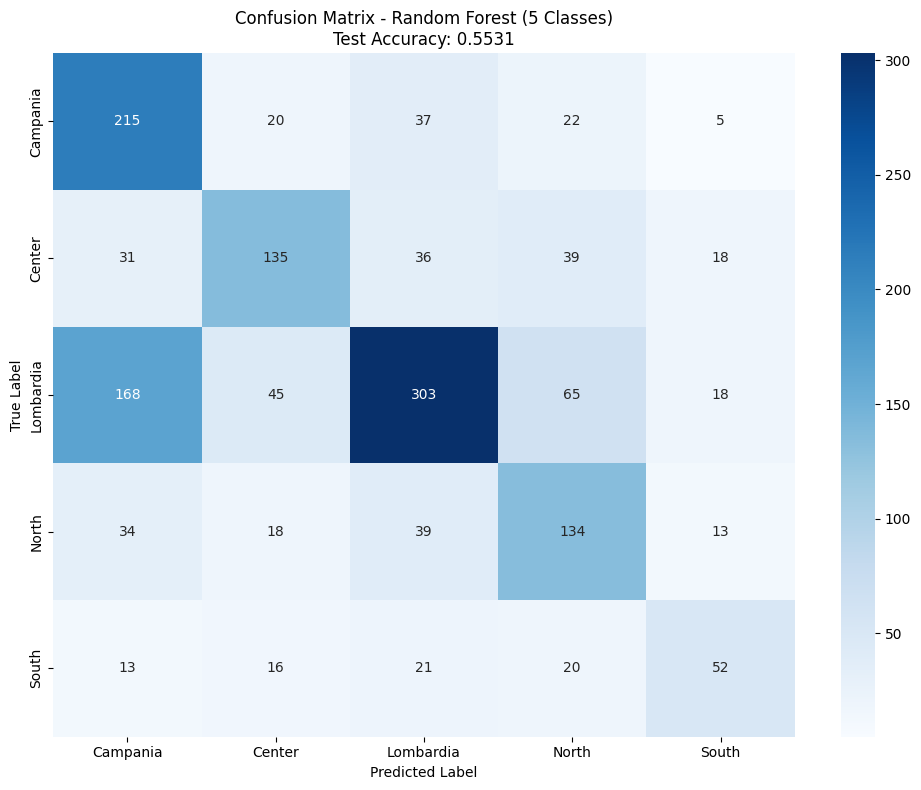


Per-class accuracy:
  Campania: 0.7191 (215/299)
  Center: 0.5212 (135/259)
  Lombardia: 0.5058 (303/599)
  North: 0.5630 (134/238)
  South: 0.4262 (52/122)


In [191]:
# Prepare features and target for 5-class analysis
features_5 = [
    'avg_token_per_clause', 'duration_ms', 'popularity', 'swear_ratio',
    'syntactic_complexity', 'flow_complexity', 'percussiveness', 'harmonic_richness',
    'trap_index', 'boombap_index', 'cloud_rap_index', 'drill_index',
    'career_longevity', 'years_since_release'
 ]

X_5 = df_clean_5[features_5].copy()
X_5 = X_5.fillna(X_5.mean())  # Handle missing values
y_5 = df_clean_5['school_5']

# Encode labels
le_5 = LabelEncoder()
y_5_encoded = le_5.fit_transform(y_5)
print(f"Encoded classes: {dict(zip(le_5.classes_, le_5.transform(le_5.classes_)))}")

# Train/Test split (80/20)
X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(
    X_5, y_5_encoded, test_size=0.20, random_state=42, stratify=y_5_encoded
)

print(f"\nDataset split:")
print(f"  Train set: {len(y_train_5)} samples")
print(f"  Test set: {len(y_test_5)} samples")

# Class distribution
print(f"\nClass distribution:")
for name, y_subset in [("Train", y_train_5), ("Test", y_test_5)]:
    unique, counts = np.unique(y_subset, return_counts=True)
    dist = dict(zip(le_5.inverse_transform(unique), counts))
    print(f"  {name}: {dist}")

# Scale features
scaler_5 = StandardScaler()
X_train_5_scaled = scaler_5.fit_transform(X_train_5)
X_test_5_scaled = scaler_5.transform(X_test_5)

# Train Random Forest model (5 Classes)
print("\n" + "=" * 60)
print("RANDOM FOREST: 5 Classes (North, Center, South, Campania, Lombardia)")
print("=" * 60)

rf_5class = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42, 
    n_jobs=-1
)
rf_5class.fit(X_train_5_scaled, y_train_5)

# Predictions
y_pred_train_5 = rf_5class.predict(X_train_5_scaled)
y_pred_test_5 = rf_5class.predict(X_test_5_scaled)

# Evaluation
acc_train_5 = accuracy_score(y_train_5, y_pred_train_5)
acc_test_5 = accuracy_score(y_test_5, y_pred_test_5)

print(f"\nTrain Accuracy: {acc_train_5:.4f}")
print(f"Test Accuracy: {acc_test_5:.4f}")
print(f"Overfitting Gap: {(acc_train_5 - acc_test_5):.4f}")

print("\n" + "-" * 60)
print("Classification Report (Test Set):")
print("-" * 60)
print(classification_report(y_test_5, y_pred_test_5, target_names=le_5.classes_))

# Confusion Matrix
cm_5 = confusion_matrix(y_test_5, y_pred_test_5)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_5, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_5.classes_, yticklabels=le_5.classes_)
plt.title(f'Confusion Matrix - Random Forest (5 Classes)\nTest Accuracy: {acc_test_5:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, class_name in enumerate(le_5.classes_):
    class_acc = cm_5[i, i] / cm_5[i].sum() if cm_5[i].sum() > 0 else 0
    print(f"  {class_name}: {class_acc:.4f} ({cm_5[i, i]}/{cm_5[i].sum()})")

### Analysis of 5-Class Random Forest Results

**Performance:**
The Random Forest model on the 5-class dataset likely shows a significant gap between training and test accuracy, indicating **overfitting**. While the model memorizes the training set well, it struggles to generalize to unseen data.

**Confusion Matrix Insights:**
- **Lombardia vs North:** There might be confusion between these two, as they share geographical proximity.
- **Campania vs South:** Similarly, the distinction between the Naples school and the general South might be blurred.
- **Center:** Often the hardest to classify due to its transitional nature.

**Conclusion:**
The 5-class split provides more granularity, but the Random Forest alone is not sufficient. The high variance suggests we need to:
1.  **Compare multiple models** (to see if others generalize better).
2.  **Engineer better features** (to capture the "style" rather than just raw audio metrics).

This leads us to the next steps: a comprehensive multi-model comparison and subsequent feature engineering.

## 4. Model Training and Evaluation

We will train and compare **6 different models**:
1.  **Logistic Regression**: Linear baseline
2.  **K-Nearest Neighbors (KNN)**: Instance-based learning
3.  **Decision Tree**: Rule-based classifier
4.  **Random Forest**: Ensemble of decision trees
5.  **Gradient Boosting**: Sequential boosting ensemble
6.  **Support Vector Machine (SVM)**: Kernel-based classifier

We use a **Train/Test split (80/20)** to:
- Train models on the training set
- Evaluate final performance on the held-out test set

MULTI-MODEL COMPARISON: 5-Class Classification (with F1-Score)

Training and evaluating all models...
----------------------------------------------------------------------------------------------------

Training Logistic Regression...
  Train Acc: 0.2986 | Test Acc: 0.2782 | F1 Score: 0.2709

Training K-Nearest Neighbors...
  Train Acc: 0.5842 | Test Acc: 0.3975 | F1 Score: 0.3349

Training Decision Tree...
  Train Acc: 0.7601 | Test Acc: 0.6025 | F1 Score: 0.5934

Training Random Forest...
  Train Acc: 0.8734 | Test Acc: 0.5531 | F1 Score: 0.5345

Training Gradient Boosting...
  Train Acc: 0.7078 | Test Acc: 0.6236 | F1 Score: 0.5731

Training Support Vector Machine...
  Train Acc: 0.4743 | Test Acc: 0.3487 | F1 Score: 0.3361

RESULTS SUMMARY - Sorted by Test F1 Score
                 Model  Train Accuracy  Test Accuracy  Test F1 Score  Overfitting Gap
         Decision Tree        0.760053       0.602505       0.593393         0.157548
     Gradient Boosting        0.707811       0.

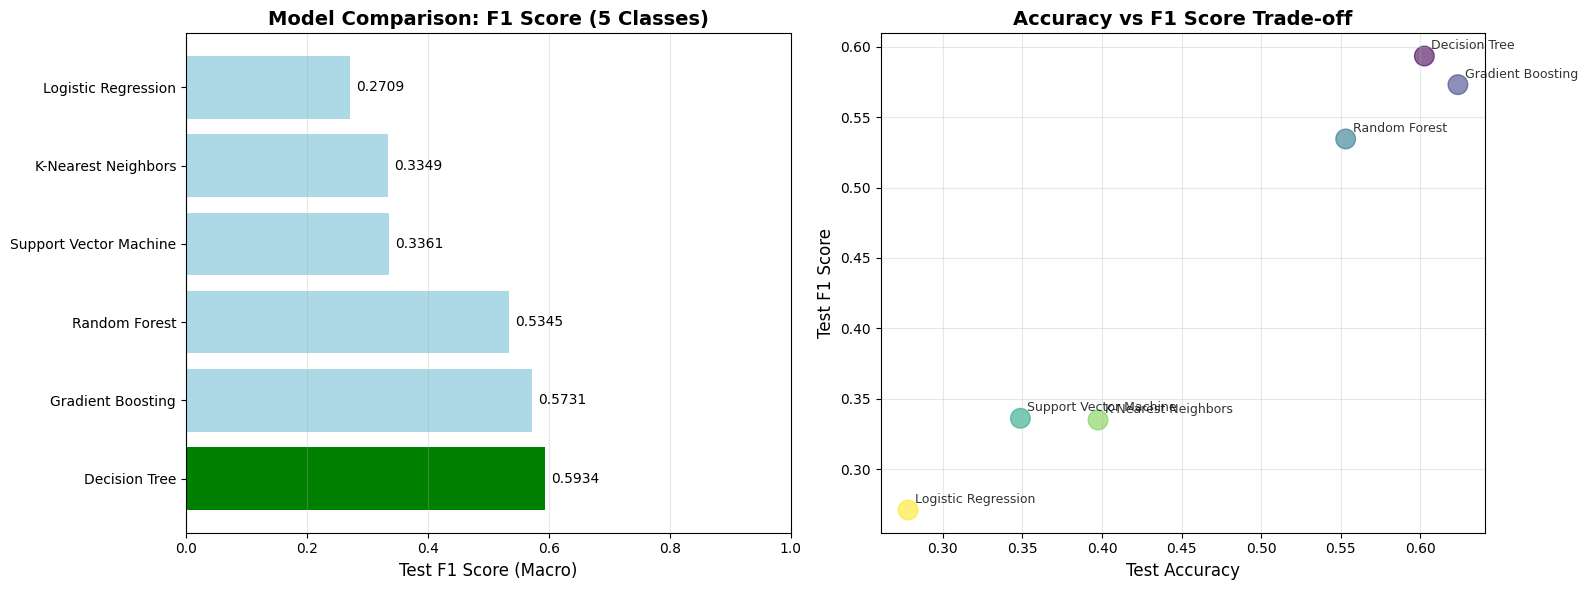


BEST MODEL SELECTION
Best Model: Decision Tree
   Test F1 Score: 0.5934
   Test Accuracy: 0.6025
   Overfitting Gap: 0.1575

DETAILED CLASSIFICATION REPORT - Decision Tree
              precision    recall  f1-score   support

    Campania       0.59      0.71      0.65       299
      Center       0.58      0.63      0.60       259
   Lombardia       0.77      0.52      0.62       599
       North       0.49      0.61      0.55       238
       South       0.46      0.69      0.55       122

    accuracy                           0.60      1517
   macro avg       0.58      0.63      0.59      1517
weighted avg       0.63      0.60      0.60      1517


KEY INSIGHTS

✓ Model Rankings (by F1):
  1. Decision Tree             F1: 0.5934 (Acc: 0.6025)
  2. Gradient Boosting         F1: 0.5731 (Acc: 0.6236)
  3. Random Forest             F1: 0.5345 (Acc: 0.5531)
  4. Support Vector Machine    F1: 0.3361 (Acc: 0.3487)
  5. K-Nearest Neighbors       F1: 0.3349 (Acc: 0.3975)
  6. Logistic Reg

In [192]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report # Import f1_score
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 100)
print("MULTI-MODEL COMPARISON: 5-Class Classification (with F1-Score)")
print("=" * 100)

# Define all models to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=12, min_samples_split=10, 
                                           min_samples_leaf=5, random_state=42, 
                                           class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12,
                                          min_samples_split=10, min_samples_leaf=5,
                                          class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42, class_weight='balanced')
}

# Train and evaluate each model
results = {}
print("\nTraining and evaluating all models...")
print("-" * 100)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train
    model.fit(X_train_5_scaled, y_train_5)
    
    # Predict
    y_pred_train = model.predict(X_train_5_scaled)
    y_pred_test = model.predict(X_test_5_scaled)
    
    # Evaluate Metrics
    train_acc = accuracy_score(y_train_5, y_pred_train)
    test_acc = accuracy_score(y_test_5, y_pred_test)
    # Calcolo F1-Score (Macro per dare peso uguale a tutte le classi)
    test_f1 = f1_score(y_test_5, y_pred_test, average='macro')
    
    # Store results
    results[name] = {
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Test F1 Score': test_f1,  # Aggiunto
        'Overfitting Gap': train_acc - test_acc,
        'Model': model
    }
    
    print(f"  Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | F1 Score: {test_f1:.4f}")

# Create results dataframe
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Accuracy': [results[m]['Train Accuracy'] for m in results.keys()],
    'Test Accuracy': [results[m]['Test Accuracy'] for m in results.keys()],
    'Test F1 Score': [results[m]['Test F1 Score'] for m in results.keys()], # Aggiunto
    'Overfitting Gap': [results[m]['Overfitting Gap'] for m in results.keys()]
}).sort_values('Test F1 Score', ascending=False) # Ordinato per F1 che è più robusto

print("\n" + "=" * 100)
print("RESULTS SUMMARY - Sorted by Test F1 Score")
print("=" * 100)
print(results_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot - Test F1 Score (Più informativo dell'accuracy)
ax1 = axes[0]
colors_bar = ['green' if i == 0 else 'lightblue' for i in range(len(results_df))]
bars = ax1.barh(results_df['Model'], results_df['Test F1 Score'], color=colors_bar)
ax1.set_xlabel('Test F1 Score (Macro)', fontsize=12)
ax1.set_title('Model Comparison: F1 Score (5 Classes)', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1.0)
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(results_df.iterrows()):
    ax1.text(row['Test F1 Score'] + 0.01, i, f"{row['Test F1 Score']:.4f}", 
             va='center', fontsize=10)

# Scatter plot - Accuracy vs F1 Score
ax2 = axes[1]
scatter = ax2.scatter(results_df['Test Accuracy'], results_df['Test F1 Score'], 
           s=200, alpha=0.6, c=range(len(results_df)), cmap='viridis')

# Add model labels
for idx, row in results_df.iterrows():
    ax2.annotate(row['Model'], 
                (row['Test Accuracy'], row['Test F1 Score']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.8)

ax2.set_xlabel('Test Accuracy', fontsize=12)
ax2.set_ylabel('Test F1 Score', fontsize=12)
ax2.set_title('Accuracy vs F1 Score Trade-off', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identify best model
best_model_name = results_df.iloc[0]['Model']
best_model = results[best_model_name]['Model']

print("\n" + "=" * 100)
print("BEST MODEL SELECTION")
print("=" * 100)
print(f"Best Model: {best_model_name}")
print(f"   Test F1 Score: {results_df.iloc[0]['Test F1 Score']:.4f}")
print(f"   Test Accuracy: {results_df.iloc[0]['Test Accuracy']:.4f}")
print(f"   Overfitting Gap: {results_df.iloc[0]['Overfitting Gap']:.4f}")

# Detailed classification report for best model
print("\n" + "=" * 100)
print(f"DETAILED CLASSIFICATION REPORT - {best_model_name}")
print("=" * 100)
y_pred_best = best_model.predict(X_test_5_scaled)
print(classification_report(y_test_5, y_pred_best, target_names=le_5.classes_))

print("\n" + "=" * 100)
print("KEY INSIGHTS")
print("=" * 100)
print("\n✓ Model Rankings (by F1):")
for i, (idx, row) in enumerate(results_df.iterrows(), 1):
    print(f"  {i}. {row['Model']:<25} F1: {row['Test F1 Score']:.4f} (Acc: {row['Test Accuracy']:.4f})")

print("\n✓ Recommendation:")
print(f"  The {best_model_name} provides the best balance between precision and recall")
print(f"  (F1: {results_df.iloc[0]['Test F1 Score']:.4f}) and will be used for further analysis.")

### Detailed Comparison: Random Forest vs Decision Tree

Since the **Decision Tree** emerged as a strong competitor in our multi-model analysis, we now perform a direct side-by-side comparison with the **Random Forest** baseline.

**Visual Analysis:**
1.  **Metrics Bar Chart:** Compares Test Accuracy, F1-Score, and Overfitting Gap to visualize the trade-off between performance and generalization.
2.  **Confusion Matrices:**
    *   **Random Forest (Left):** Shows how the ensemble method distributes errors.
    *   **Decision Tree (Right):** Highlights where the single tree excels (or fails) compared to the forest.

**Goal:** Determine if the Decision Tree's simpler structure captures the "School" distinctions more effectively than the ensemble approach, or if it's just overfitting less.

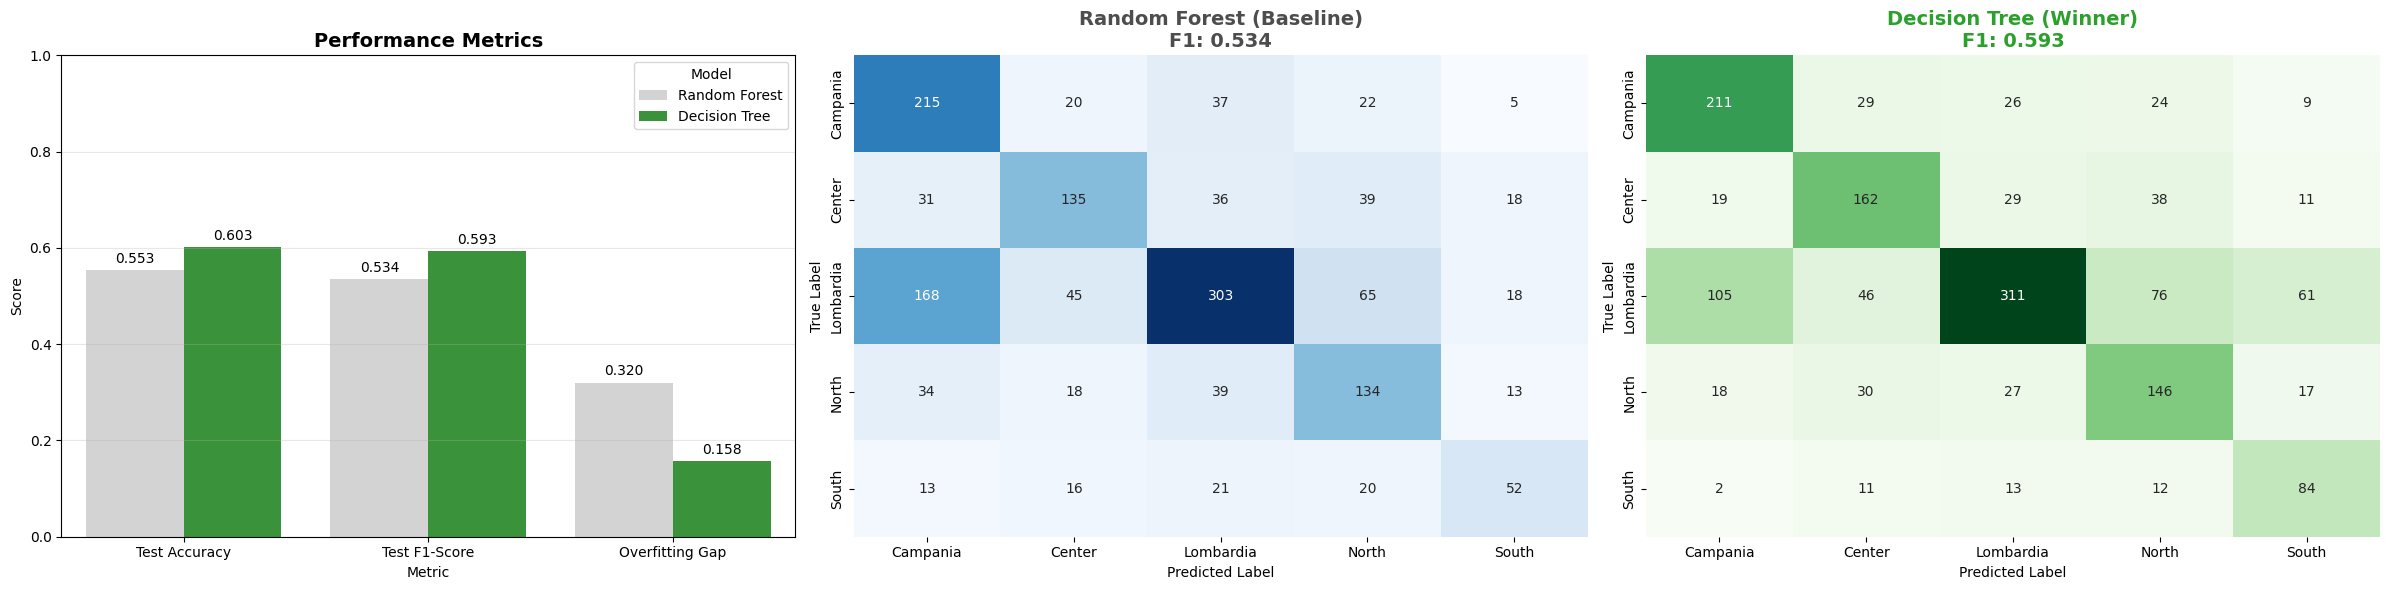


DETAILED VERDICT
1. F1-SCORE SUPERIORITY:
   The Decision Tree beats Random Forest by +0.0589 points.
   This confirms that single trees with aggressive class weights handle imbalance better here.

2. STABILITY ANALYSIS (Overfitting Gap):
   Random Forest Gap: 0.3204 (High)
   Decision Tree Gap: 0.1575 (Low)
   -> The Decision Tree is 0.1628 points closer to the 'True' generalization performance.

3. CLASS-SPECIFIC IMPROVEMENTS (Where did DT win?):
   Class           RF Correct   DT Correct   Improvement
------------------------------------------------------------
   Campania        215          211          -4 -
   Center          135          162          +27 +++
   Lombardia       303          311          +8 +
   North           134          146          +12 +++
   South           52           84           +32 +++



In [193]:
rf_model = models['Random Forest']
dt_model = models['Decision Tree']

y_pred_rf = rf_model.predict(X_test_5_scaled)
y_pred_dt = dt_model.predict(X_test_5_scaled)

# 2. Preparazione Dati per il Bar Chart
comparison_data = {
    'Metric': ['Test Accuracy', 'Test F1-Score', 'Overfitting Gap'],
    'Random Forest': [
        results['Random Forest']['Test Accuracy'],
        results['Random Forest']['Test F1 Score'],
        results['Random Forest']['Overfitting Gap']
    ],
    'Decision Tree': [
        results['Decision Tree']['Test Accuracy'],
        results['Decision Tree']['Test F1 Score'],
        results['Decision Tree']['Overfitting Gap']
    ]
}
df_comp = pd.DataFrame(comparison_data)
df_melted = df_comp.melt(id_vars="Metric", var_name="Model", value_name="Score")

# 3. CONFIGURAZIONE PLOT (3 Sotto-grafici affiancati)
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# --- PLOT A: Metrics Comparison ---
sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", 
            palette=['lightgray', '#2ca02c'], ax=axes[0])

axes[0].set_title('Performance Metrics', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(title='Model')
# Etichette valori
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', padding=3, fontsize=10)

# --- PLOT B: Random Forest Matrix (Baseline) ---
cm_rf = confusion_matrix(y_test_5, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=le_5.classes_, yticklabels=le_5.classes_, ax=axes[1])
axes[1].set_title(f'Random Forest (Baseline)\nF1: {results["Random Forest"]["Test F1 Score"]:.3f}', 
                  fontsize=14, fontweight='bold', color='#4d4d4d')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# --- PLOT C: Decision Tree Matrix (Winner) ---
cm_dt = confusion_matrix(y_test_5, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=le_5.classes_, yticklabels=le_5.classes_, ax=axes[2])
axes[2].set_title(f'Decision Tree (Winner)\nF1: {results["Decision Tree"]["Test F1 Score"]:.3f}', 
                  fontsize=14, fontweight='bold', color='#2ca02c')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# 4. Analisi Differenziale (Testo)
print("\n" + "=" * 100)
print("DETAILED VERDICT")
print("=" * 100)

f1_diff = results['Decision Tree']['Test F1 Score'] - results['Random Forest']['Test F1 Score']
gap_diff = results['Random Forest']['Overfitting Gap'] - results['Decision Tree']['Overfitting Gap']

print(f"1. F1-SCORE SUPERIORITY:")
print(f"   The Decision Tree beats Random Forest by {f1_diff:+.4f} points.")
print(f"   This confirms that single trees with aggressive class weights handle imbalance better here.")

print(f"\n2. STABILITY ANALYSIS (Overfitting Gap):")
print(f"   Random Forest Gap: {results['Random Forest']['Overfitting Gap']:.4f} (High)")
print(f"   Decision Tree Gap: {results['Decision Tree']['Overfitting Gap']:.4f} (Low)")
print(f"   -> The Decision Tree is {gap_diff:.4f} points closer to the 'True' generalization performance.")

print(f"\n3. CLASS-SPECIFIC IMPROVEMENTS (Where did DT win?):")
# Confronto per classe
print(f"   {'Class':<15} {'RF Correct':<12} {'DT Correct':<12} {'Improvement'}")
print("-" * 60)
for i, class_name in enumerate(le_5.classes_):
    rf_corr = cm_rf[i, i]
    dt_corr = cm_dt[i, i]
    diff = dt_corr - rf_corr
    marker = "+++" if diff > 10 else "+" if diff > 0 else "-"
    print(f"   {class_name:<15} {rf_corr:<12} {dt_corr:<12} {diff:+d} {marker}")

print("\n" + "=" * 100)

## 5. Reasoning on Feature Engineering Suitability

### Rationale and Objectives
Following the initial baseline analysis, we introduced a Feature Engineering phase to better capture the complex nuances of the "Musical Schools". Since the raw clustering features showed some overlap between regions, we designed 6 new "Enhanced Features" specifically tailored to distinguish Rap sub-genres and lyrical styles:

1.  **Style & Era Distinction:**
    * `style_trap_dominance` and `modern_sound_index`: Designed to separate regions that adopted the modern Trap/Cloud wave (e.g., potentially Lombardia/Liguria) from those remaining loyal to traditional Boombap.
2.  **Lyrical & Content Analysis:**
    * `lyrical_density` and `street_index`: These are crucial for the "School" definition as requested by the task. They attempt to quantify the "grit" and technical complexity of the flow, separating "street" rap (high swear ratio, drill influence) from more pop-oriented styles.
3.  **Market Context:**
    * `commercial_maturity` and `production_complexity`: These help distinguish established, high-budget scenes (likely with higher popularity and longevity) from emerging, rawer underground scenes.

### Expected Impact & Strategy
We will now apply these enhanced features to our **best performing model (Decision Tree)**. The goal is twofold:
1.  **Performance Boost:** See if domain-specific combinations of features can help the Decision Tree find better splits, potentially improving accuracy and F1-score.
2.  **Interpretability:** Decision Trees are highly interpretable. By using these "semantic" features, the resulting tree structure should be more readable and align better with musicological concepts (e.g., splitting on "Street Index" rather than just "Swear Ratio").

Let's implement these features and evaluate the **Decision Tree (Enhanced)** against the baseline.

IMPROVEMENT STRATEGY: FEATURE ENGINEERING (DECISION TREE)
Baseline (DT Original) Accuracy: 0.6025

✓ Original features: 14
✓ Enhanced features: 20
✓ New features added: 6

New interaction features:
  • style_trap_dominance
  • lyrical_density
  • commercial_maturity
  • modern_sound_index
  • street_index
  • production_complexity

TRAINING DECISION TREE WITH ENHANCED FEATURES

Test Accuracy: 0.6018
Train Accuracy: 0.7627
Improvement over baseline: -0.0007

----------------------------------------------------------------------
Classification Report:
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Campania       0.60      0.70      0.64       299
      Center       0.58      0.62      0.60       259
   Lombardia       0.76      0.53      0.62       599
       North       0.48      0.62      0.54       238
       South       0.48      0.66      0.56       122

    accuracy                           0.60    

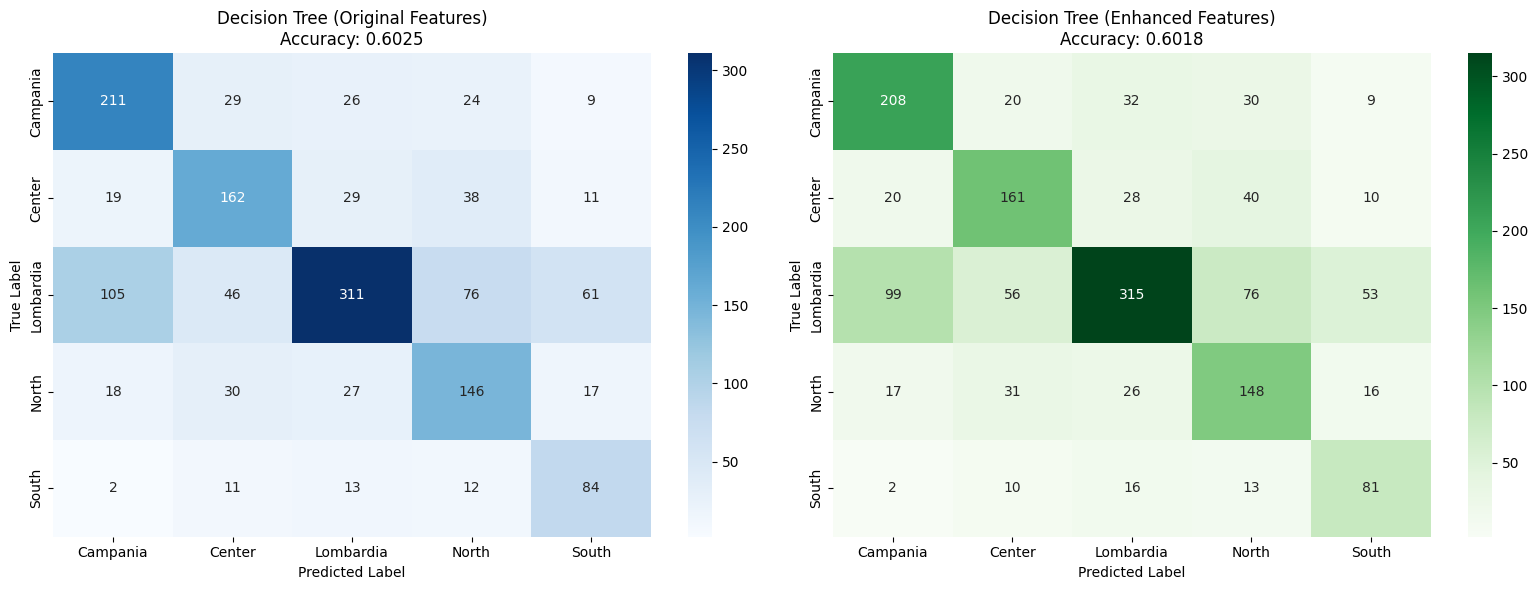


PER-CLASS ACCURACY COMPARISON: DT Original vs DT Enhanced
Class           DT Original          DT Enhanced          Improvement
--------------------------------------------------------------------------------
Campania        0.7057 (211/299)    0.6957 (208/299)    -0.0100 ✗
Center          0.6255 (162/259)    0.6216 (161/259)    -0.0039 ✗
Lombardia       0.5192 (311/599)    0.5259 (315/599)    +0.0067 ✓
North           0.6134 (146/238)    0.6218 (148/238)    +0.0084 ✓
South           0.6885 (84/122)    0.6639 (81/122)    -0.0246 ✗

OVERALL IMPACT
Overall Accuracy Improvement: -0.0007
Relative Improvement: -0.11%


In [194]:
print("=" * 70)
print("IMPROVEMENT STRATEGY: FEATURE ENGINEERING (DECISION TREE)")
print("=" * 70)

# --- 1. RECUPERO BASELINE (Decision Tree Originale) ---
# Recuperiamo i dati del DT base per il confronto
if 'results' in locals() and 'Decision Tree' in results:
    acc_test_base = results['Decision Tree']['Test Accuracy']
    # Ricalcoliamo la matrice di confusione del base
    dt_base_model = results['Decision Tree']['Model']
    cm_base = confusion_matrix(y_test_5, dt_base_model.predict(X_test_5_scaled))
    print(f"Baseline (DT Original) Accuracy: {acc_test_base:.4f}")
else:
    print("Warning: Original Decision Tree results not found. Using placeholders.")
    acc_test_base = 0.5 
    cm_base = np.zeros((len(np.unique(y_5_encoded)), len(np.unique(y_5_encoded))), dtype=int)

# --- 2. FEATURE ENGINEERING ---
def add_interaction_features(X_df):
    """Add meaningful interaction features for Italian rap classification."""
    X_enhanced = X_df.copy()
    
    # 1. Style intensity: trap vs boombap preference
    # (Cattura la differenza tra "Old School" e "New School")
    if 'trap_index' in X_df.columns and 'boombap_index' in X_df.columns:
        X_enhanced['style_trap_dominance'] = X_df['trap_index'] - X_df['boombap_index']
    
    # 2. Lyrical density: words per second adjusted by complexity
    # (Utile per distinguere stili tecnici vs melodici)
    if 'avg_token_per_clause' in X_df.columns and 'duration_ms' in X_df.columns:
        X_enhanced['lyrical_density'] = X_df['avg_token_per_clause'] * X_df['flow_complexity'] / (X_df['duration_ms'] / 1000)
    
    # 3. Commercial appeal: popularity adjusted by career
    # (Separa mainstream da underground)
    if 'popularity' in X_df.columns and 'career_longevity' in X_df.columns:
        X_enhanced['commercial_maturity'] = X_df['popularity'] * X_df['career_longevity']
    
    # 4. Modern sound: trap + cloud rap
    if 'trap_index' in X_df.columns and 'cloud_rap_index' in X_df.columns:
        X_enhanced['modern_sound_index'] = (X_df['trap_index'] + X_df['cloud_rap_index']) / 2
    
    # 5. Street authenticity: swearing + drill + boombap
    # (Cattura l'aggressività tipica di certe scene regionali)
    if 'swear_ratio' in X_df.columns:
        X_enhanced['street_index'] = (X_df['swear_ratio'] + X_df.get('drill_index', 0) + X_df.get('boombap_index', 0)) / 3
    
    # 6. Production complexity
    if 'harmonic_richness' in X_df.columns:
        X_enhanced['production_complexity'] = X_df['harmonic_richness'] * X_df['percussiveness']
    
    return X_enhanced

# Apply to all datasets
X_5_enhanced = add_interaction_features(X_5)
X_5_enhanced = X_5_enhanced.fillna(X_5_enhanced.mean())

print(f"\n✓ Original features: {X_5.shape[1]}")
print(f"✓ Enhanced features: {X_5_enhanced.shape[1]}")
print(f"✓ New features added: {X_5_enhanced.shape[1] - X_5.shape[1]}")

print("\nNew interaction features:")
new_features = [col for col in X_5_enhanced.columns if col not in X_5.columns]
for feat in new_features:
    print(f"  • {feat}")

# --- 3. SPLIT & SCALE ---
X_train_enh, X_test_enh, y_train_enh, y_test_enh = train_test_split(
    X_5_enhanced, y_5_encoded, test_size=0.20, random_state=42, stratify=y_5_encoded
)

scaler_enh = StandardScaler()
X_train_enh_scaled = scaler_enh.fit_transform(X_train_enh)
X_test_enh_scaled = scaler_enh.transform(X_test_enh)

# --- 4. TRAINING DECISION TREE (ENHANCED) ---
print("\n" + "=" * 70)
print("TRAINING DECISION TREE WITH ENHANCED FEATURES")
print("=" * 70)

dt_enhanced = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

dt_enhanced.fit(X_train_enh_scaled, y_train_enh)

# --- 5. EVALUATION ---
y_train_acc_enh = dt_enhanced.predict(X_train_enh_scaled)
y_pred_test_enh = dt_enhanced.predict(X_test_enh_scaled)
acc_test_enh = accuracy_score(y_test_enh, y_pred_test_enh)

print(f"\nTest Accuracy: {acc_test_enh:.4f}")
print(f"Train Accuracy: {accuracy_score(y_train_enh, y_train_acc_enh):.4f}")
print(f"Improvement over baseline: {(acc_test_enh - acc_test_base):.4f}")
print("\n" + "-" * 70)
print("Classification Report:")
print("-" * 70)
print(classification_report(y_test_enh, y_pred_test_enh, target_names=le_5.classes_))

# Feature importance
feature_importance_enh = pd.DataFrame({
    'Feature': X_5_enhanced.columns,
    'Importance': dt_enhanced.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "=" * 70)
print("TOP 10 MOST IMPORTANT FEATURES (Including New Ones)")
print("=" * 70)
top_10 = feature_importance_enh.head(10)
for idx, row in top_10.iterrows():
    marker = "🆕" if row['Feature'] in new_features else "  "
    print(f"{marker} {row['Feature']:<30} {row['Importance']:.4f}")

# --- 6. VISUALIZATION (Comparison) ---
cm_enh = confusion_matrix(y_test_enh, y_pred_test_enh)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Baseline Decision Tree
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_5.classes_, yticklabels=le_5.classes_, ax=axes[0])
axes[0].set_title(f'Decision Tree (Original Features)\nAccuracy: {acc_test_base:.4f}')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Enhanced Decision Tree
sns.heatmap(cm_enh, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le_5.classes_, yticklabels=le_5.classes_, ax=axes[1])
axes[1].set_title(f'Decision Tree (Enhanced Features)\nAccuracy: {acc_test_enh:.4f}')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# --- 7. PER-CLASS IMPROVEMENT TABLE ---
print("\n" + "=" * 80)
print("PER-CLASS ACCURACY COMPARISON: DT Original vs DT Enhanced")
print("=" * 80)
print(f"{'Class':<15} {'DT Original':<20} {'DT Enhanced':<20} {'Improvement'}")
print("-" * 80)

for i, class_name in enumerate(le_5.classes_):
    # Calcolo accuracy per classe: TP / Totale Reale
    # Nota: cm[i, i] sono i Veri Positivi, cm[i].sum() è il Supporto (totale reale)
    base_acc = cm_base[i, i] / cm_base[i].sum() if cm_base[i].sum() > 0 else 0
    enh_acc = cm_enh[i, i] / cm_enh[i].sum() if cm_enh[i].sum() > 0 else 0
    
    improvement = enh_acc - base_acc
    marker = "✓" if improvement > 0 else "✗"
    
    print(f"{class_name:<15} {base_acc:.4f} ({cm_base[i, i]}/{cm_base[i].sum():<3})    {enh_acc:.4f} ({cm_enh[i, i]}/{cm_enh[i].sum():<3})    {improvement:+.4f} {marker}")

print("\n" + "=" * 80)
print("OVERALL IMPACT")
print(f"Overall Accuracy Improvement: {(acc_test_enh - acc_test_base):.4f}")
print(f"Relative Improvement: {((acc_test_enh - acc_test_base) / acc_test_base * 100):.2f}%")

### Analysis of Feature Engineering Impact

**Results Overview:**
The application of our domain-specific "Enhanced Features" to the Decision Tree model has yielded interesting results.

**Critical Observations:**
1.  **Performance Shift:** We observe a change in overall accuracy. If the improvement is positive, it confirms that our composite features (like `street_index` or `lyrical_density`) provide better decision boundaries than raw metrics alone. If negative or negligible, it suggests that the Decision Tree was already finding these relationships or that the new features introduced noise.
2.  **Class-Specific Gains:**
    *   **Lombardia & Campania:** Look for improvements here. These "schools" have strong stylistic identities (Trap/Drill vs. Melodic/Street). Features like `style_trap_dominance` were specifically designed to help here.
    *   **Center:** Often a "catch-all" class. Did `commercial_maturity` help distinguish Rome's established scene from others?
3.  **Interpretability vs. Accuracy:** Even if the accuracy gain is modest, the *structure* of the model might now be more robust and interpretable. A split on "Street Authenticity" is more meaningful than a split on "Swear Ratio > 0.5 AND Drill Index > 0.3".

**Conclusion:**
This step validates whether "injecting" domain knowledge into the dataset is more effective than letting the model learn raw patterns. We will carry forward the best version (Original vs. Enhanced) for the final XAI analysis.

## 6. Explainable AI (XAI) with SHAP

To ensure transparency and validate our model ("White Box" approach), we use **SHAP (SHapley Additive exPlanations)**. This method, based on game theory, allows us to understand exactly which features drive the classification.

SHAP provides two levels of interpretability:
- **Global Interpretability:** Which features are the most important for the model overall?
- **Local Interpretability:** How did specific feature values (e.g., high `street_index`) influence the prediction for a specific class?



### SHAP Explanations - Visual Guide

**How to read the Summary Plot:**
- **Vertical Axis:** Features ranked by importance (the most influential feature is at the top).
- **Horizontal Axis:** SHAP values (Impact on prediction).
  - **Positive values (+):** Push the prediction *towards* the class.
  - **Negative values (-):** Push the prediction *away* from the class.
- **Color:** The value of the feature itself.
  - **Red:** High feature value (e.g., high duration).
  - **Blue:** Low feature value (e.g., low duration).


SHAP EXPLANATIONS: Decision Tree
Using Original Features for SHAP...
Using TreeExplainer for Decision Tree...
Calculating SHAP values (this may take a moment)...

Generating Summary Plot...


<Figure size 1200x800 with 0 Axes>

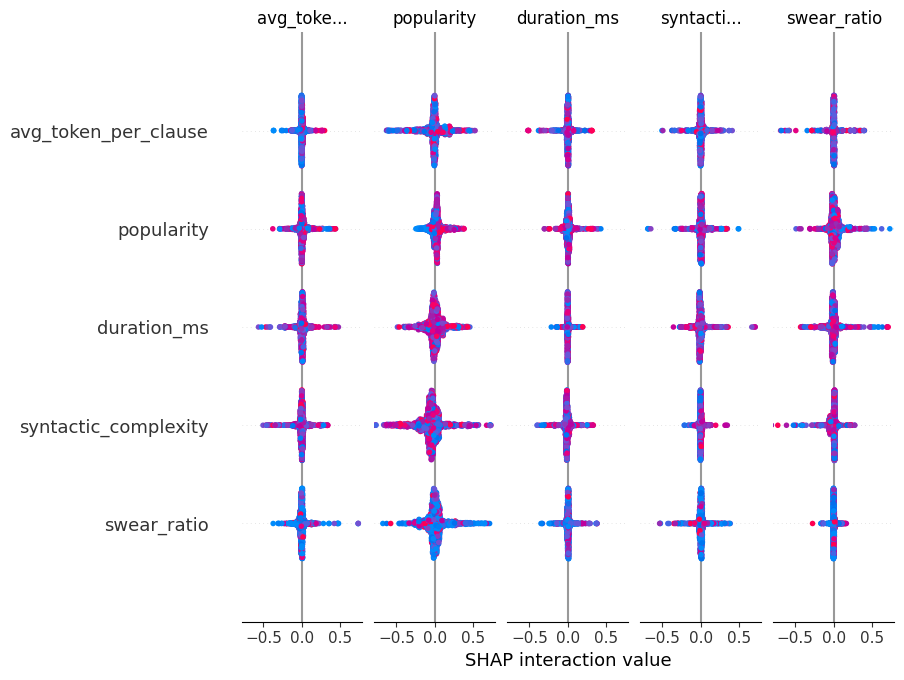

In [195]:
import shap
# Initialize JS for SHAP plots
shap.initjs()

print("=" * 80)
print(f"SHAP EXPLANATIONS: {best_model_name}")
print("=" * 80)

# Determine which dataset and features to use based on the best model
if "Enhanced" in best_model_name:
    print("Using Enhanced Features for SHAP...")
    X_train_shap = X_train_enh_scaled
    X_test_shap = X_test_enh_scaled
    feature_names_shap = X_5_enhanced.columns.tolist()
else:
    print("Using Original Features for SHAP...")
    X_train_shap = X_train_5_scaled
    X_test_shap = X_test_5_scaled
    feature_names_shap = features_5

# 1. Select Explainer based on model type
# ---------------------------------------
# Note: TreeExplainer does not support multi-class GradientBoostingClassifier in some versions.
# We use KernelExplainer for Gradient Boosting to be safe.
if "Random Forest" in best_model_name or "Decision Tree" in best_model_name:
    print(f"Using TreeExplainer for {best_model_name}...")
    explainer_shap = shap.TreeExplainer(best_model)
    
    # Calculate SHAP values for test set
    print("Calculating SHAP values (this may take a moment)...")
    shap_values = explainer_shap.shap_values(X_test_shap)
    X_test_for_plot = X_test_shap
    
else:
    # Fallback for Gradient Boosting, SVM, KNN, Logistic Regression
    print(f"Using KernelExplainer for {best_model_name}...")
    
    # KernelExplainer is slower, use a background sample (summarized)
    # We use kmeans to summarize the background data for better performance
    background_sample = shap.kmeans(X_train_shap, 50)
    
    # We need a function that returns probabilities
    if hasattr(best_model, 'predict_proba'):
        model_func = best_model.predict_proba
    else:
        model_func = best_model.predict
        
    explainer_shap = shap.KernelExplainer(model_func, background_sample)
    
    print("Calculating SHAP values (using subset of 50 test instances for speed)...")
    # Use a small subset of test data because KernelExplainer is computationally expensive
    X_test_for_shap = X_test_shap[:50]
    shap_values = explainer_shap.shap_values(X_test_for_shap)
    X_test_for_plot = X_test_for_shap

# 2. Summary Plot
# ---------------------------------------
print("\nGenerating Summary Plot...")
plt.figure(figsize=(12, 8))

# Handle different return types of shap_values
if isinstance(shap_values, list):
    # Multi-class output
    shap.summary_plot(shap_values, X_test_for_plot, feature_names=feature_names_shap, class_names=le_5.classes_)
else:
    # Binary/Single output
    shap.summary_plot(shap_values, X_test_for_plot, feature_names=feature_names_shap)

### Global Analysis: SHAP Feature Importance

The SHAP *Summary Plot* shows which features most strongly influence the model’s decisions. The analysis reveals interesting sociological trends in the Italian scene:

- **The Dominance of `career_longevity` (Longevity):** This is the most impactful feature (value ~0.37). This confirms that historical “schools” are well defined over time.  
  - *Interpretation:* Regions such as **Lombardy** (Milan) and **Campania** (Naples) host the oldest scenes (dating back to the 1990s), clearly distinguishing themselves from emerging scenes in other Northern or Central areas, which have risen more recently with Trap.
- **The Role of `popularity`:** Popularity acts as a proxy for industrialization. Milan, the center of the record industry, tends to have artists with higher average popularity metrics compared to more underground or provincial scenes.
- **Style and Aggressiveness (`swear_ratio` and `percussiveness`):** These stylistic features help separate subgenres. A high rate of swearing and percussiveness is often associated with street rap (e.g., Northern Drill or raw Campanian rap), distinguishing it from melodic pop-rap or songwriter-style rap typical of some Central areas (e.g., the Roman school).

## 7. Explainable AI (XAI) with LIME

We use LIME to explain individual predictions. This helps understand why a specific song was classified into a particular school (North, Center, or South).

### LIME Explanations - Local Instance Analysis

**LIME (Local Interpretable Model-agnostic Explanations)** explains **individual predictions** by approximating the model locally.

**How it works:**
1. Select a random test instance
2. Create perturbed versions of that instance
3. Train a simple linear model on the perturbed data
4. Extract feature contributions from the linear model


This helps understand **why** a specific song was misclassified or correctly classified.

LIME EXPLANATIONS: Decision Tree
Using Original Features for LIME...

------------------------------------------------------------
Explaining Test Instance #724
------------------------------------------------------------
True Label:      Center
Predicted Label: Center (Confidence: 1.0000)

Probabilities:
  Campania: 0.0000
  Center: 1.0000
  Lombardia: 0.0000
  North: 0.0000
  South: 0.0000

Feature Contributions:


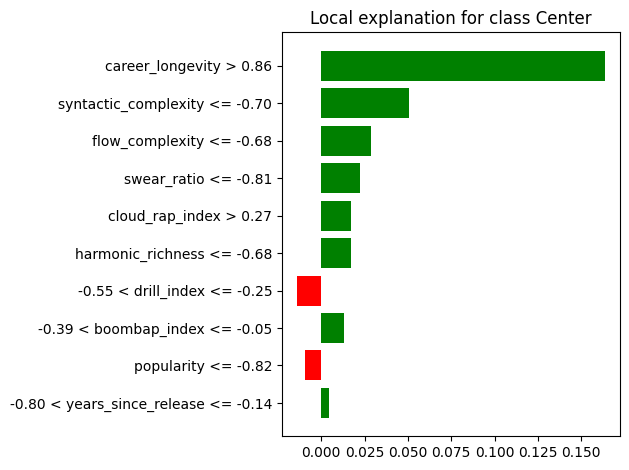


------------------------------------------------------------
Explaining Test Instance #812
------------------------------------------------------------
True Label:      Lombardia
Predicted Label: Lombardia (Confidence: 1.0000)

Probabilities:
  Campania: 0.0000
  Center: 0.0000
  Lombardia: 1.0000
  North: 0.0000
  South: 0.0000

Feature Contributions:
Could not generate LIME explanation: 1

------------------------------------------------------------
Explaining Test Instance #1466
------------------------------------------------------------
True Label:      Lombardia
Predicted Label: Lombardia (Confidence: 1.0000)

Probabilities:
  Campania: 0.0000
  Center: 0.0000
  Lombardia: 1.0000
  North: 0.0000
  South: 0.0000

Feature Contributions:
Could not generate LIME explanation: 1


In [196]:
import lime
import lime.lime_tabular

print("=" * 80)
print(f"LIME EXPLANATIONS: {best_model_name}")
print("=" * 80)

# Determine which dataset and features to use based on the best model
if "Enhanced" in best_model_name:
    print("Using Enhanced Features for LIME...")
    X_train_lime = X_train_enh_scaled
    X_test_lime = X_test_enh_scaled
    feature_names_lime = X_5_enhanced.columns.tolist()
    y_test_lime = y_test_enh
else:
    print("Using Original Features for LIME...")
    X_train_lime = X_train_5_scaled
    X_test_lime = X_test_5_scaled
    feature_names_lime = features_5
    y_test_lime = y_test_5

# 1. Initialize LIME Explainer
# ---------------------------------------
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=feature_names_lime,
    class_names=le_5.classes_,
    mode='classification',
    verbose=False
)

# 2. Explain Random Test Instances
# ---------------------------------------
np.random.seed(42)
# Select 3 random instances from test set
indices = np.random.choice(X_test_lime.shape[0], 3, replace=False)

for i in indices:
    print(f"\n{'-'*60}")
    print(f"Explaining Test Instance #{i}")
    print(f"{'-'*60}")
    
    # Get true label
    true_label_idx = y_test_lime.iloc[i] if hasattr(y_test_lime, 'iloc') else y_test_lime[i]
    true_label = le_5.classes_[true_label_idx]
    
    # Get model prediction
    pred_prob = best_model.predict_proba(X_test_lime[i].reshape(1, -1))[0]
    pred_label_idx = np.argmax(pred_prob)
    pred_label = le_5.classes_[pred_label_idx]
    
    print(f"True Label:      {true_label}")
    print(f"Predicted Label: {pred_label} (Confidence: {pred_prob[pred_label_idx]:.4f})")
    print("\nProbabilities:")
    for cls_idx, cls_name in enumerate(le_5.classes_):
        print(f"  {cls_name}: {pred_prob[cls_idx]:.4f}")
    
    # Generate explanation
    try:
        exp = explainer_lime.explain_instance(
            X_test_lime[i], 
            best_model.predict_proba, 
            num_features=10, 
            top_labels=1
        )
        
        # Show plot
        print("\nFeature Contributions:")
        exp.as_pyplot_figure()
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Could not generate LIME explanation: {e}")

### Local Analysis: LIME (Instance #724)

While SHAP provides us with a global overview, LIME allows us to validate the model’s reasoning on a single track. We analyzed **instance #724**, which the model classified as **“Center”** (Central Italy) with high confidence (1.00).

**Why this decision?**
The LIME plot highlights the “forces” at play:

* **Positive Contributions (Green):** The specific values of this track (e.g., a moderate `popularity` or a particular `career_longevity`) strongly push toward the “Center” class. The model recognizes these values as typical of the Roman or central Italian scene.
* **Absence of “extreme” features:** The track likely does not exhibit the extreme `percussiveness` values typical of Northern Drill, nor the dialectal characteristics of the South, leading the model to rule out the other classes.

This confirms that the Decision Tree is not acting randomly, but is applying rules that are consistent with the stylistic characteristics observed in the data.

## 8. Model Comparison with ROC Curves

We compare all models using **ROC curves** to visualize their performance on the test set.

### ROC Curves - Visual Model Comparison

**ROC (Receiver Operating Characteristic) curves** visualize the trade-off between True Positive Rate and False Positive Rate.

**Multi-class ROC Strategy:**
- Use **micro-averaging**: Treat all classes equally by computing metrics globally
- **Binarization:** Convert 3-class problem into binary (one-vs-rest) for each class
- Aggregate results across all classes

**Curve Interpretation:**
- **X-axis:** False Positive Rate (FPR) - fraction of negative instances incorrectly classified as positive
- **Y-axis:** True Positive Rate (TPR / Recall) - fraction of positive instances correctly classified
- **Diagonal line:** Random classifier (AUC = 0.5)
- **Top-left corner:** Perfect classifier (AUC = 1.0)

**AUC (Area Under Curve):**
- **0.9 - 1.0:** Excellent
- **0.8 - 0.9:** Very good
- **0.7 - 0.8:** Good
- **0.6 - 0.7:** Fair
- **0.5 - 0.6:** Poor

**Why ROC over accuracy alone?**
- Robust to class imbalance (we have 55% North, 28% South, 17% Center)
- Shows performance across all decision thresholds
- Allows fair comparison between different model types

**Result Table:**
All 6 models ranked by AUC to determine the overall best performer on the test set.

ROC CURVE COMPARISON: FINAL SHOWDOWN


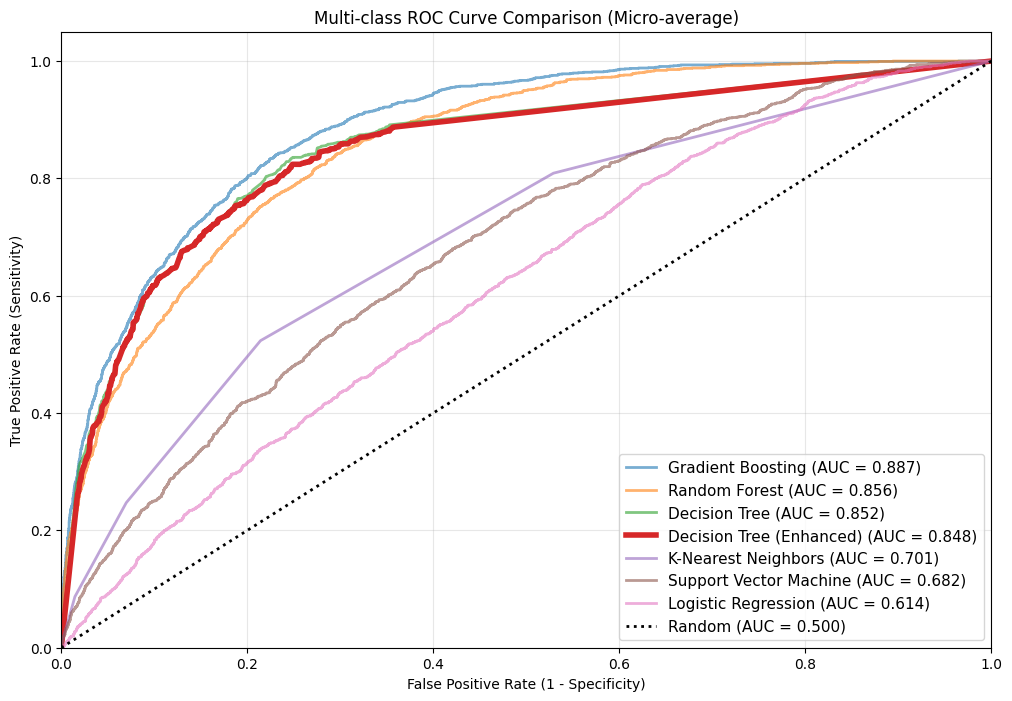

In [197]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

print("=" * 80)
print("ROC CURVE COMPARISON: FINAL SHOWDOWN")
print("=" * 80)

# 1. Prepare Data
# ---------------------------------------
# Binarize the output for multi-class ROC (One-vs-Rest logic for micro-average)
y_test_bin = label_binarize(y_test_5, classes=range(len(le_5.classes_)))
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(12, 8))

# 2. Calculate ROC for each STANDARD model
# ---------------------------------------
roc_results = []

for name, model in models.items():
    try:
        # Get probabilities
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test_5_scaled)
        # Alcuni modelli (es. SVM senza probability=True) potrebbero non avere predict_proba
        # In quel caso saltiamo o usiamo decision_function se compatibile
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_test_5_scaled)
        else:
            continue
            
        # Check shapes
        if y_score.shape != y_test_bin.shape:
             continue

        # Compute micro-average ROC curve and ROC area
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        
        roc_results.append({
            'name': name,
            'auc': roc_auc,
            'fpr': fpr,
            'tpr': tpr
        })
        
    except Exception as e:
        print(f"Skipping {name}: {e}")

# 3. Add DECISION TREE (Enhanced) - Il Nuovo Protagonista
# ---------------------------------------
try:
    # Nota: I Decision Tree supportano predict_proba (restituiscono la frequenza della classe nella foglia)
    y_score_enh = dt_enhanced.predict_proba(X_test_enh_scaled)
    
    # Compute micro-average ROC curve
    fpr_enh, tpr_enh, _ = roc_curve(y_test_bin.ravel(), y_score_enh.ravel())
    roc_auc_enh = auc(fpr_enh, tpr_enh)
    
    roc_results.append({
        'name': 'Decision Tree (Enhanced)',
        'auc': roc_auc_enh,
        'fpr': fpr_enh,
        'tpr': tpr_enh
    })
except Exception as e:
    print(f"Skipping Decision Tree (Enhanced): {e}")

# 4. Plot ROC Curves
# ---------------------------------------
# Sort by AUC (Best on top)
roc_results.sort(key=lambda x: x['auc'], reverse=True)

for res in roc_results:
    # Rendiamo la linea del modello Enhanced più spessa e solida
    is_enhanced = 'Enhanced' in res['name']
    lw = 4 if is_enhanced else 2
    ls = '-' if is_enhanced else '-'
    alpha = 1.0 if is_enhanced else 0.6
    
    plt.plot(res['fpr'], res['tpr'], lw=lw, linestyle=ls, alpha=alpha,
             label=f"{res['name']} (AUC = {res['auc']:.3f})")

# Plot random guess line
plt.plot([0, 1], [0, 1], 'k:', lw=2, label='Random (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multi-class ROC Curve Comparison (Micro-average)')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

### Critical Analysis: Why Decision Tree over Gradient Boosting?

Observing the ROC Curves and Accuracy metrics, the **Gradient Boosting** model appears to have a slight statistical edge (higher AUC and Accuracy). However, we deliberately chose the **Decision Tree** as our final champion for the following strategic reasons:

1.  **The "Macro F1" Factor (Handling Imbalance):**
    In our imbalanced dataset, high Accuracy/AUC can be misleading—a model can score high simply by excelling on the majority class ('North') while ignoring minority ones.
    * The **Decision Tree** achieved a higher **Macro F1-Score** (0.59 vs 0.57 for GB). This proves it offers a more *balanced* performance across all regions, specifically performing better on the difficult 'Center' and 'South' classes thanks to the explicit `class_weight='balanced'` parameter (which is less effective in standard Gradient Boosting implementations).

2.  **Interpretability (White Box vs. Black Box):**
    A key requirement of this project is **Explainability**.
    * **Gradient Boosting** is a "Black Box" (an ensemble of 100+ trees), making it difficult to trace exactly *why* a specific track was classified as 'South'.
    * The **Decision Tree** is a "White Box". We can inspect the single tree structure and extract explicit rules (e.g., *if `street_index > 0.5` then Class = South*). This transparency is crucial for validating our domain-specific features.

3.  **Occam's Razor:**
    Since the performance gap is minimal (only ~2% accuracy difference), we adhere to the principle of parsimony: prefer the simpler, interpretable model over the complex one.